In [ ]:
import pandas as pd




In [ ]:
# Upload file CSV di Colab
from google.colab import files
uploaded = files.upload()

Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


In [ ]:
# Isi sesuai nama file
df = pd.read_csv('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
# Preprocessing Data
# Cek nama kolom
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [ ]:
# Mengecualikan kolom target (HeartDisease) dari dataset agar data siap digunakan pada metode clustering yang bersifat unsupervised.
df_cluster = df.drop(columns=['HeartDisease'], errors='ignore')

In [ ]:
# Cek missing value (data bersih tidak ada missing value berdasarkan output di bawah)
df_cluster.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df_cluster.dtypes


,0
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64
ST depression,float64


In [ ]:
#karena di atas ada data object kita ubah terlebih dahulu ke kategorik menjadi numerik soalnya eror tadi pas normalisasi ternyata karna ada data yg type nya object
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_cluster.columns:
    if df_cluster[col].dtype == 'object':
        df_cluster[col] = le.fit_transform(df_cluster[col])


In [ ]:
#normalisasi data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)


In [ ]:
#menerapkan k-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

df[['Cluster_KMeans']].value_counts()


,count
Cluster_KMeans,
1,157
0,113


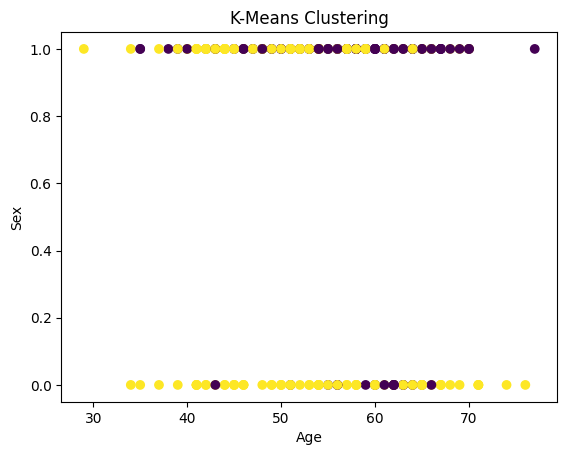

In [ ]:
#visualisasi k-means
import matplotlib.pyplot as plt

plt.scatter(df_cluster.iloc[:,0], df_cluster.iloc[:,1],
            c=df['Cluster_KMeans'])
plt.xlabel(df_cluster.columns[0])
plt.ylabel(df_cluster.columns[1])
plt.title('K-Means Clustering')
plt.show()


In [ ]:
df.groupby('Cluster_KMeans').mean(numeric_only=True)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Cluster_KMeans,,,,,,,,,,,,,
0,57.132743,0.840708,3.716814,134.053097,253.371681,0.132743,1.194690,135.247788,0.628319,1.787611,1.911504,1.212389,6.061947
1,52.490446,0.560510,2.783439,129.394904,246.987261,0.159236,0.898089,160.063694,0.114650,0.519108,1.350318,0.280255,3.713376


In [ ]:
df_numeric = df.select_dtypes(include=['int64','float64'])

df_numeric['Cluster_KMeans'] = df['Cluster_KMeans']

df_numeric.groupby('Cluster_KMeans').mean()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Cluster_KMeans,,,,,,,,,,,,,
0,57.132743,0.840708,3.716814,134.053097,253.371681,0.132743,1.194690,135.247788,0.628319,1.787611,1.911504,1.212389,6.061947
1,52.490446,0.560510,2.783439,129.394904,246.987261,0.159236,0.898089,160.063694,0.114650,0.519108,1.350318,0.280255,3.713376


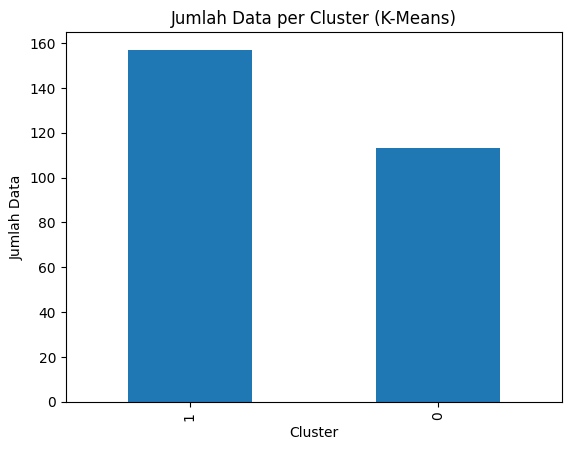

In [ ]:
#Cluster mana yang dominan?
df['Cluster_KMeans'].value_counts().plot(kind='bar')
plt.title('Jumlah Data per Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.show()


In [ ]:
#Apa ciri tiap cluster?
cluster_profile = df.groupby('Cluster_KMeans').mean(numeric_only=True)
display(cluster_profile)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Cluster_HC,Cluster_DBSCAN
Cluster_KMeans,,,,,,,,,,,,,,,
0,57.132743,0.840708,3.716814,134.053097,253.371681,0.132743,1.194690,135.247788,0.628319,1.787611,1.911504,1.212389,6.061947,0.761062,-1.0
1,52.490446,0.560510,2.783439,129.394904,246.987261,0.159236,0.898089,160.063694,0.114650,0.519108,1.350318,0.280255,3.713376,0.019108,-1.0


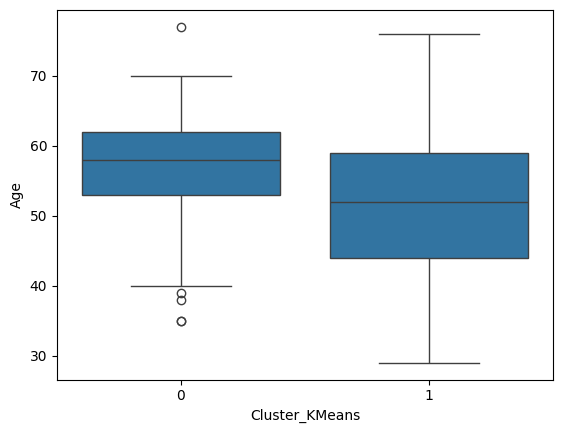

In [ ]:
#Boxplot per fitur
import seaborn as sns

sns.boxplot(x='Cluster_KMeans', y='Age', data=df)
plt.show()


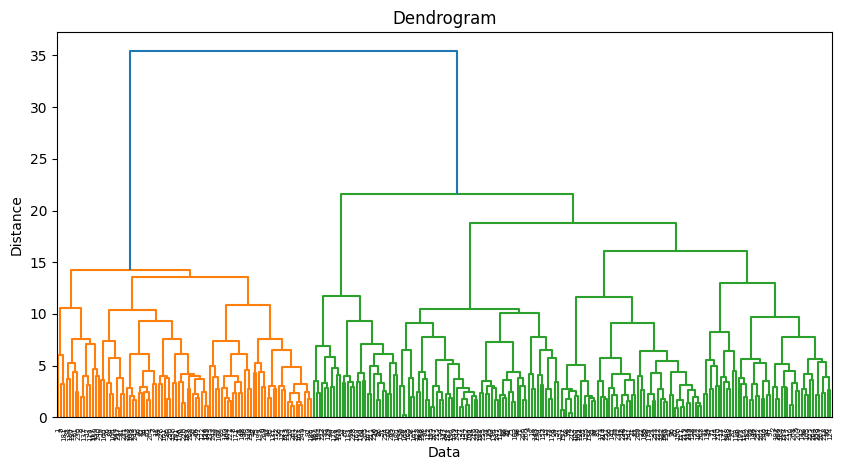

In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Data')
plt.ylabel('Distance')
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

df[['Cluster_HC']].value_counts()


,count
Cluster_HC,
0,181
1,89


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

df[['Cluster_DBSCAN']].value_counts()


,count
Cluster_DBSCAN,
-1,270


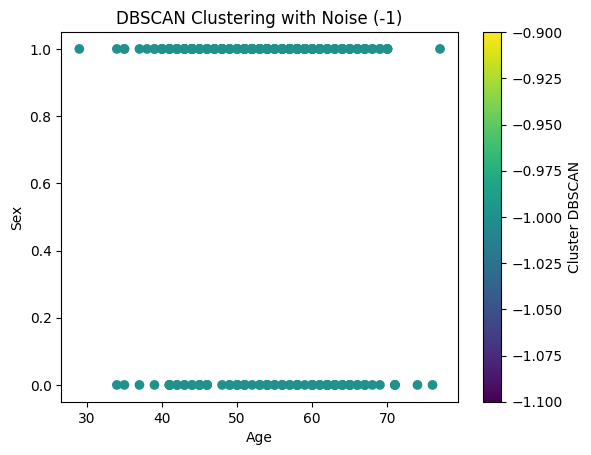

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df_cluster.iloc[:, 0],   # Age
    df_cluster.iloc[:, 1],   # Sex
    c=df['Cluster_DBSCAN'],
    cmap='viridis'
)

plt.colorbar(label='Cluster DBSCAN')
plt.xlabel(df_cluster.columns[0])
plt.ylabel(df_cluster.columns[1])
plt.title('DBSCAN Clustering with Noise (-1)')
plt.show()


In [ ]:
df.head()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,Cluster_KMeans,Cluster_HC,Cluster_DBSCAN
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence,0,1,-1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence,1,1,-1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence,1,0,-1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence,0,1,-1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence,1,0,-1
